In [1]:
import os
import math
import json
import warnings
import itertools

warnings.filterwarnings("ignore")

In [2]:
os.environ.setdefault("FINTORCH_BASE_TIME_FRAME", "60")

'60'

In [3]:
import numpy as np 
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

from fintorch.enum import TimeFrame
from fintorch.exchange import ONLINE_EXCHANGE
from fintorch.utils.preprocess import remove_price_dependency
from fintorch.utils.args import DefaultArgumentParser
from fintorch.utils.plot import draw_candlestick_plot, draw_labels, draw_predictions

In [4]:
string_args = [
    "--start-date", "2024-01-01",
    "--stop-date", "2024-06-01",
    "--time-frame", "60",
    "--symbol", "BTC-USDT"
]

args = DefaultArgumentParser.parse(args=string_args)

In [5]:
sdf = ONLINE_EXCHANGE.future.data.get_candles_dataframe(symbol=args.symbol, time_frame=args.time_frame).copy()

sdf

,open,high,low,close,volume,trade
timestamp,,,,,,
1705395660,43032.7,43040.0,42985.6,43003.7,201.772,3323
1705395720,43004.5,43016.0,42960.0,42967.3,534.556,4093
1705395780,42967.3,42976.5,42954.2,42957.8,117.148,1847
1705395840,42957.9,42965.7,42928.9,42942.2,245.105,3502
1705395900,42942.3,42953.0,42919.0,42942.6,134.988,1928
...,...,...,...,...,...,...
1711406100,70419.7,70438.9,70406.9,70438.8,79.550,1522
1711406160,70438.7,70524.7,70438.7,70510.3,134.209,2770
1711406220,70510.3,70510.4,70437.2,70464.4,78.321,1687


In [116]:
df = remove_price_dependency(df=sdf.copy())[:1000]
df["cmax"] = df.close.rolling(window=21, center=True).max()
df["fractal"] = df.close == df.cmax
df = np.round(df, 6)
df = df.dropna()

df

,open,high,low,close,volume,trade,cmax,fractal
timestamp,,,,,,,,
1705396260,-0.002623,-0.001882,-0.002881,-0.001938,144.802,1678,0.000840,False
1705396320,-0.001938,-0.001835,-0.002459,-0.001966,100.250,1747,0.001804,False
1705396380,-0.001966,-0.001966,-0.002520,-0.002466,46.979,1289,0.002673,False
1705396440,-0.002466,-0.002194,-0.003121,-0.003030,249.853,2298,0.002796,False
1705396500,-0.003030,-0.002471,-0.003030,-0.002683,52.615,1042,0.002796,False
...,...,...,...,...,...,...,...,...
1705454760,0.004072,0.004074,0.003481,0.003669,164.773,1455,0.004072,False
1705454820,0.003669,0.004120,0.003530,0.004016,65.320,1189,0.004072,False
1705454880,0.004016,0.004102,0.003831,0.003984,74.212,972,0.004072,False


In [117]:
def create_model(points):
    x = np.array([point[0] for point in points]).reshape(-1, 1)
    y = np.array([point[1] for point in points]).reshape(-1, 1)
    model = LinearRegression()
    model.fit(x, y)

    return model

def calculate_error(model, point):
    x_hat = np.array(point[0]).reshape(1, 1)
    y_hat = np.round(model.predict(x_hat), 6).item()
    error = np.round(abs(point[1] - y_hat), 6)

    return error

In [118]:
fractals = [(index, df.close.iloc[index]) for index in range(len(df)) if df.fractal.iloc[index]]

lines = []
points = []
for current in tqdm(fractals):
    if 0 == len(points):
        points.append(current)

    elif 1 == len(points):
        if current[1] < points[-1][1]:
            points.append(current)
            model = create_model(points)
            
        else:
            points = [current]

    else:
        error = calculate_error(model, current)

        # print(points)
        # print(current)
        # print(error)

        if error < 0.001:
            points.append(current)
            model = create_model(points)

        elif 0.01 < error:
            if 2 < len(points):
                lines.append((model, points[0][0], points[-1][0]))
                
            points = [current]

        #     print("#" * 64)
            
        # print("=" * 32)

  0%|          | 0/32 [00:00<?, ?it/s]

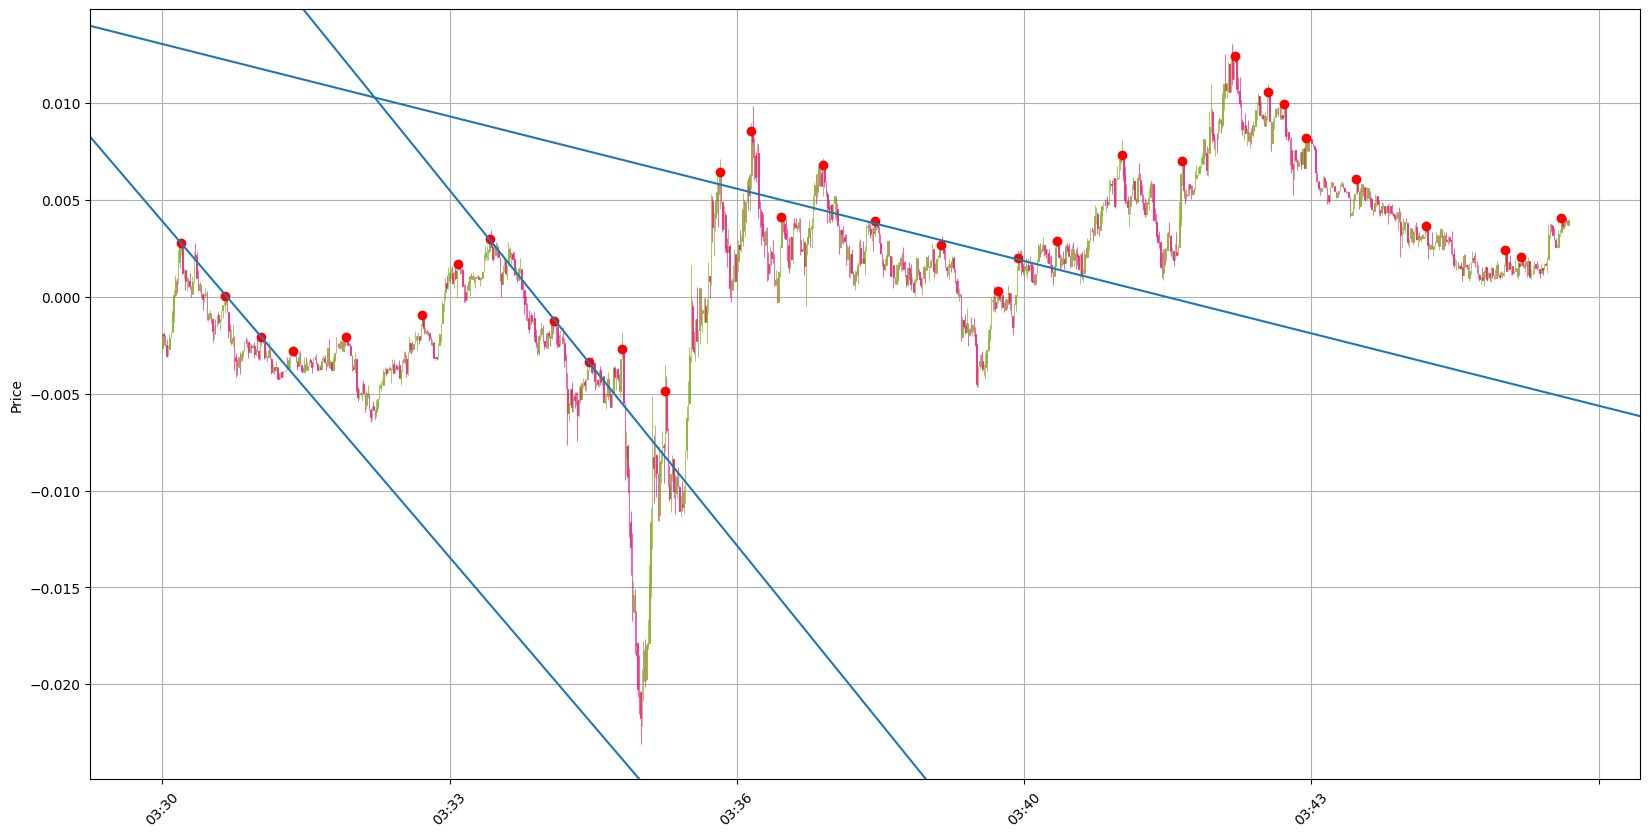

In [119]:
pdf = df[:1000]
pdf = pdf.reset_index()

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(20, 10))

draw_candlestick_plot(ax=ax, df=pdf)
ax.plot(pdf.cmax[pdf.fractal], "ro")
for model, start_index, stop_index in lines:
    xy1 = (start_index, model.predict([[start_index]]).item())
    xy2 = (stop_index, model.predict([[stop_index]]).item())
    ax.axline(xy1, xy2)
    
ax.grid()

In [499]:
tdf = df.copy()

bars_list, profits_list = [], []
entry_price, entry_index = None, None
for index in tqdm(range(len(tdf))):    
    if entry_price is None:
        if tdf.buy.iloc[index]:
            entry_index = index
            entry_price = tdf["stop-buy"].iloc[index]
            stop_loss_price = tdf["stop-sell"].iloc[index]
            
            print()
            print("IDX:", entry_index)
            print("EN: ", entry_price)
            print("SL: ", stop_loss_price)
            print("TP: ", take_profit_price)
            print()
            
    else:
        if stop_loss_price < tdf["stop-sell"].iloc[index]:
            stop_loss_price = tdf["stop-sell"].iloc[index]
            # print("New SL:", stop_loss_price)

        exit_price = None
        if tdf.low.iloc[index] <= stop_loss_price:
            exit_price = stop_loss_price
            fee = 0.001
        elif not tdf.buy.iloc[index]:
            exit_price = tdf.close.iloc[index]
            fee = 0.0005
        
        if exit_price is not None:
            bars = index - entry_index 
            profit = exit_price / entry_price - 1 - fee

            
            print()
            print("IDX: ", index)
            print("SL:  ", stop_loss_price)
            print("PNL: ", profit)
            print("BARS:", bars)
            print("=" * 32)
            print()

            
            profits_list.append(profit)
            bars_list.append(bars)
            
            entry_index = None
            entry_price = None


    # if 10 < len(profits_list):
    #     break

  0%|          | 0/100129 [00:00<?, ?it/s]

AttributeError: 'DataFrame' object has no attribute 'buy'

In [440]:
LEVERAGE = 50

bars = np.array(bars_list)
profits = np.array(profits_list) * LEVERAGE

days = len(tdf) * TimeFrame.MIN1 // TimeFrame.DAY1
min_bars = bars.min()
max_bars = bars.max()
mean_bars = bars.mean()

trades = len(profits)
daily_trades = len(profits) // days

net_profit = profits.sum()
compound_profit = (1 + profits).prod() - 1
daily_net_profit = net_profit / days
daily_compound_profit = (compound_profit + 1) ** (1 / days) - 1

wining_ratio = (0 < profits).sum() / len(profits) * 100

# print statements
print("{:<32}{}".format("Days", days))
print()
print("{:<32}{}".format("Min bars", min_bars))
print("{:<32}{:}".format("Max bars", max_bars))
print("{:<32}{:.2f}".format("Mean bars", mean_bars))
print()
print("{:<32}{}".format("Trades", trades))
print("{:<32}{}".format("Daily trades", daily_trades))
print()
print("{:<32}{:.2f}".format("Net profit", net_profit))
print("{:<32}{:.2f}".format("Compound profit", compound_profit))
print("{:<32}{:.2f}".format("Daily net profit", daily_net_profit))
print("{:<32}{:.2f}".format("Daily compound profit", daily_compound_profit))
print()
print("{:<32}{:.2f}%".format("Wining ratio", wining_ratio))


Days                            69

Min bars                        1
Max bars                        31
Mean bars                       4.33

Trades                          3450
Daily trades                    50

Net profit                      -17.39
Compound profit                 -1.00
Daily net profit                -0.25
Daily compound profit           -0.35

Wining ratio                    28.26%
